<a href="https://colab.research.google.com/github/lavaeagle2/colab/blob/ml-practise-and-models/forest_power_eda_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌳 Forest Power + EDA

## 📦 Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## 📊 Load Dataset

In [ ]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['target'] = df['target'].map({0: 'malignant', 1: 'benign'})
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


## 🔍 Basic EDA

In [ ]:
print(df.shape)
print(df.isnull().sum())
print(df['target'].value_counts())

(569, 31)
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64
target
benign       357
malignant    212
Name: count, dtype: int64


## 📊 Target Distribution

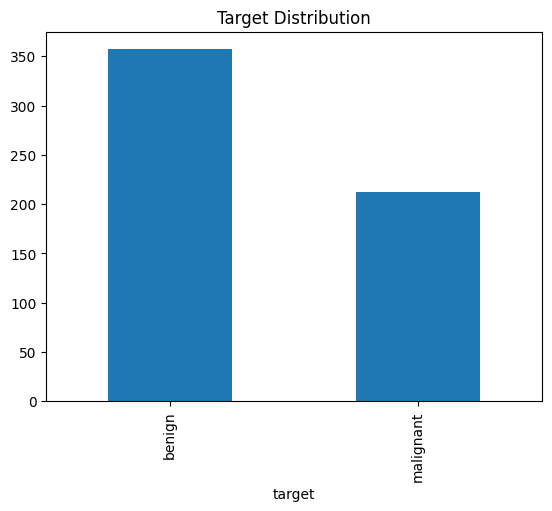

In [ ]:
df['target'].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.show()

## 🔥 Correlation Heatmap

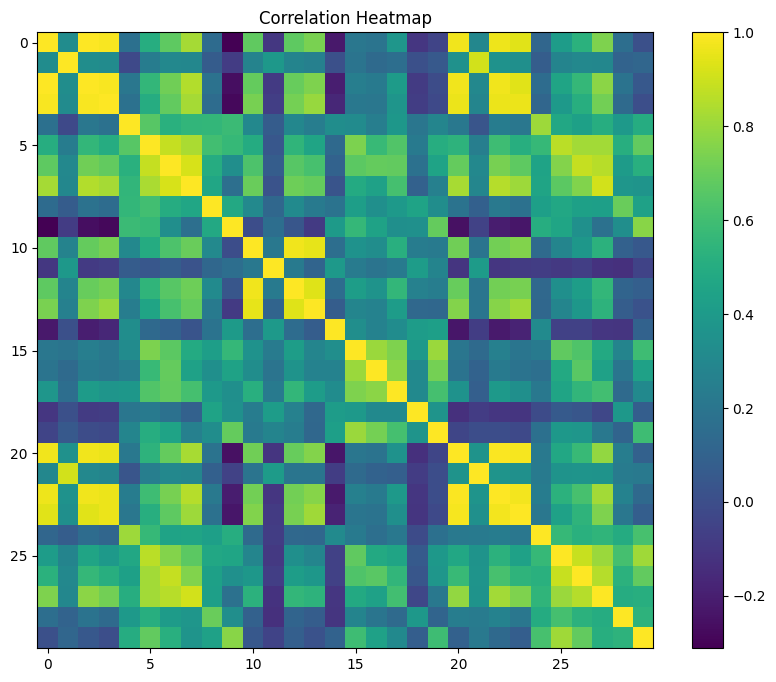

In [ ]:
import numpy as np
corr = df.drop('target', axis=1).corr()
plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.colorbar()
plt.title('Correlation Heatmap')
plt.show()

## 📉 Feature Distributions

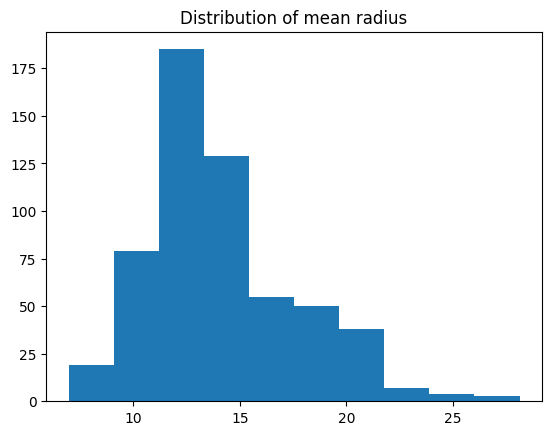

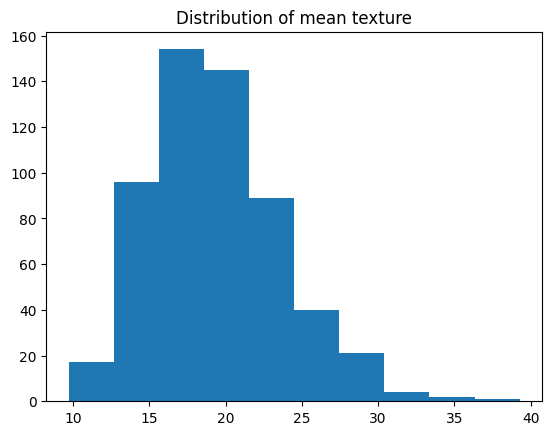

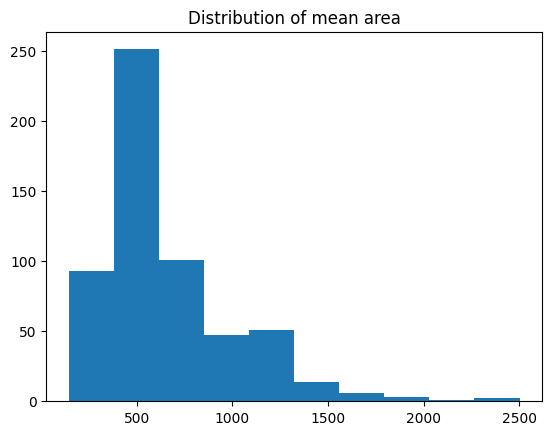

In [ ]:
features = ['mean radius', 'mean texture', 'mean area']
for col in features:
    plt.figure()
    plt.hist(df[col])
    plt.title(f'Distribution of {col}')
    plt.show()

## 🎯 Train-Test Split

In [ ]:
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 🌲 Decision Tree

In [ ]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
acc_tree = accuracy_score(y_test, tree.predict(X_test))
acc_tree

0.9415204678362573

## 🌳 Random Forest (5 Trees)

In [ ]:
rf = RandomForestClassifier(n_estimators=5, random_state=42)
rf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf.predict(X_test))
acc_rf

0.9649122807017544

In [ ]:
rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf.predict(X_test))
acc_rf

0.9649122807017544

In [ ]:
rf = RandomForestClassifier(n_estimators=20, random_state=42)
rf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf.predict(X_test))
acc_rf

0.9707602339181286

In [ ]:
rf = RandomForestClassifier(n_estimators=25, random_state=42)
rf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf.predict(X_test))
acc_rf

0.9707602339181286

In [ ]:
rf = RandomForestClassifier(n_estimators=35, random_state=42)
rf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf.predict(X_test))
acc_rf

0.9707602339181286

In [ ]:
rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf.predict(X_test))
acc_rf

0.9707602339181286

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf.predict(X_test))
acc_rf

0.9707602339181286

## 🌟 Feature Importance

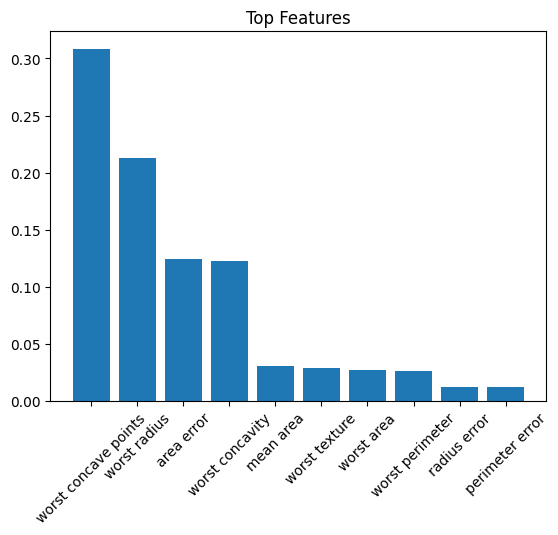

In [ ]:
imp = pd.Series(rf.feature_importances_, index=data.feature_names)
imp = imp.sort_values(ascending=False)
plt.figure()
plt.bar(imp.head(10).index, imp.head(10).values)
plt.xticks(rotation=45)
plt.title('Top Features')
plt.show()

## 📈 Accuracy vs Trees

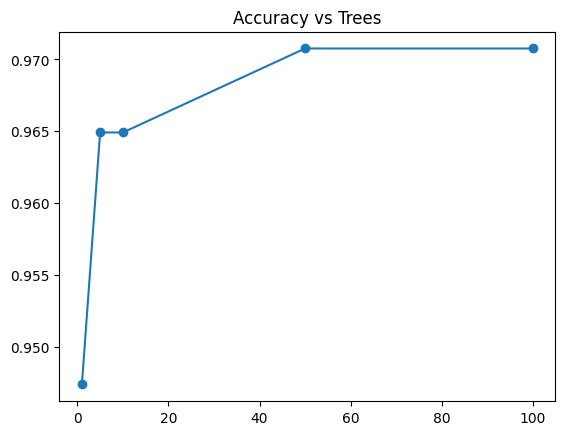

In [ ]:
trees = [1,5,10,50,100]
accs = []
for n in trees:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    accs.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure()
plt.plot(trees, accs, marker='o')
plt.title('Accuracy vs Trees')
plt.show()